# 00 — Analyse exploratoire et prétraitement
**Prévision multivariée de la production PV totale du réseau SENELEC par PatchTST**

| Élément | Choix |
|---|---|
| Données | `energie.xlsx` — journal horaire SENELEC, 01/01/2019 → 09/05/2023 |
| Cible | `PV_total` (MW) = somme des 11 centrales PV |
| Entrées interdites (R4) | productions PV individuelles, `Total_unites`, `RI`, `RGI_*` (contiennent le PV) |
| Covariables | contexte réseau (3), cycliques (6), géométrie solaire (2) |
| Découpage (R1) | Train 2019–2021 · Val 01–09/2022 · Test 10/2022–05/2023 |

**Plan du notebook**
1. Chargement et contrôle de la grille horaire
2. Construction de la cible (écrêtage, imputation causale, traçabilité par centrale)
3. Valeurs manquantes
4. Saisonnalité : profil journalier, ACF, périodogramme
5. Non-stationnarité : mises en service et capacité apparente
6. Covariables : cycliques, géométrie solaire, contexte réseau
7. Corrélations
8. Découpage temporel et normalisation (sans fuite)
9. Conclusions pour la modélisation

In [1]:
# --- Environnement commun à tous les notebooks -------------------------------
import sys, warnings
from pathlib import Path
RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m          # module commun de l'étude (entièrement commenté)
import figures_style as fs       # charte graphique des figures de l'article
fs.appliquer()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)

## 1. Chargement et contrôle de la grille horaire

In [ ]:
brut = pd.read_excel(m.CHEMIN_DONNEES)
print(f"Lignes du fichier : {len(brut):,} | colonnes : {brut.shape[1]}")
print(f"Période : {brut['Horodatage_debut'].min()} → {brut['Horodatage_debut'].max()}")
ecarts = brut['Horodatage_debut'].diff().value_counts()
print("Écarts entre horodatages consécutifs :"); print(ecarts.to_string())
journal = m.charger_journal()
print(f"Grille horaire complète : {len(journal):,} h → {journal['Heure'].isna().sum()} heures absentes du fichier (NaN)")

Lignes du fichier : 37,872 | colonnes : 51
Période : 2019-01-01 00:00:00 → 2023-05-09 23:00:00
Écarts entre horodatages consécutifs :
Horodatage_debut
0 days 01:00:00    37863
1 days 01:00:00        6
3 days 01:00:00        2


FileNotFoundError: [Errno 2] No such file or directory: 'F:\\Mes_Documents_de_these\\DOCUMENTS_RECHERCHE\\DOCUMENTS_DE_REPPORTS\\Projet_Articles_These\\Production_forecasting\\PatchTST\\PatchTST_comparaisonPV\\data\\energie.xlsx'

> **Lecture.** Le pas est horaire. Les 288 heures absentes correspondent à 8 sauts d'un ou trois jours. La grille est
> complétée pour rester régulière (condition du fenêtrage) ; les heures ajoutées sont imputées de manière causale.

## 2. Construction de la cible `PV_total`

In [ ]:
jeu = m.construire_jeu(cache=False)          # pipeline complet (cf. module, sections 1–3)
tab = jeu.tableau
print(f"Décalage solaire estimé sur Train : {jeu.decalage_solaire_h:+.2f} h")
jeu.diagnostic_cible

Décalage solaire estimé sur Train : +0.50 h


,centrale,mise_en_service,dernier_releve,seuil_MW,valeurs_ecretees,lacunes_imputees,moyenne_MW,max_MW
0,PV-Mbour,2019-01-01 07:00:00,2023-05-09 18:00:00,22.73,14,1032,3.97,20.38
1,PV-CICAD,2019-01-01 07:00:00,2023-04-11 19:00:00,4.37,36,710,0.26,4.00
2,PV Kahone,2019-01-01 06:00:00,2021-01-25 18:00:00,19.08,1,454,1.57,16.15
3,PV ERS Kahone,2021-01-26 07:00:00,2023-05-09 19:00:00,18.09,13,244,1.97,17.14
4,PV Scaling Kahone,2021-01-26 12:00:00,2023-05-09 18:00:00,39.34,1,779,3.21,34.16
5,PV Kael Touba,2021-03-26 07:00:00,2023-05-09 18:00:00,30.20,1,200,2.80,29.62
6,PV-Bokhol,2019-01-01 07:00:00,2023-05-09 19:00:00,23.10,11,901,4.16,23.09
7,PV Mékhé Mérina,2019-01-01 07:00:00,2023-05-09 18:00:00,24.28,24,522,5.63,20.60
8,PV S Mekhe Santhiou,2019-01-01 07:00:00,2023-05-09 19:00:00,25.16,0,1066,5.58,24.72
9,PV DIASS,2019-06-12 06:00:00,2023-05-09 19:00:00,22.32,1,829,3.45,20.97


**Règles appliquées à chaque centrale** (module, fonction `construire_cible`) :
- seuil d'écrêtage = 1,2 × quantile 99,9 % **calculé sur Train** : les valeurs supérieures (ex. 958 MW à Mbour) sont des erreurs de saisie ;
- hors période d'existence (avant la mise en service, après le retrait) : production nulle ;
- lacunes ≤ 3 h : interpolation linéaire ; au-delà : moyenne de la même heure sur les 7 jours **précédents**.

Les productions individuelles ne servent qu'à construire la cible : elles ne sont **jamais** des entrées du modèle.

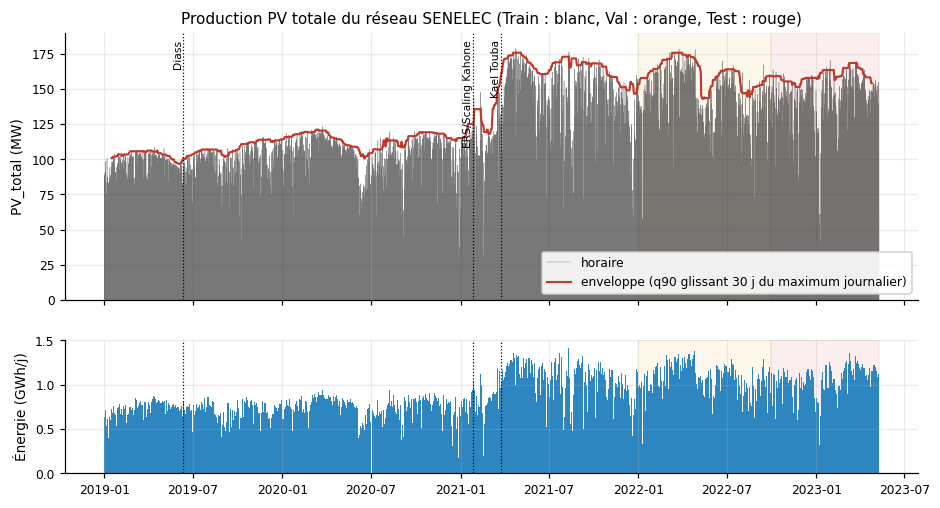

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(tab.index, tab[m.CIBLE], lw=0.25, color=fs.COULEURS["observe"], alpha=0.6, label="horaire")
jmax = tab[m.CIBLE].resample("D").max()
ax[0].plot(jmax.index, jmax.rolling(30, center=True).quantile(0.9), color=fs.COULEURS["modele"], lw=1.4,
           label="enveloppe (q90 glissant 30 j du maximum journalier)")
ev = {"Diass": "2019-06-12", "ERS/Scaling Kahone": "2021-01-26", "Kael Touba": "2021-03-26"}
for k, d in ev.items():
    for a in ax: a.axvline(pd.Timestamp(d), color="k", ls=":", lw=0.8)
    ax[0].text(pd.Timestamp(d), 185, k, rotation=90, va="top", ha="right", fontsize=7)
for a in ax:
    a.axvspan(m.DEBUT_VAL, m.DEBUT_TEST, color=fs.COULEURS["val"], alpha=0.08)
    a.axvspan(m.DEBUT_TEST, tab.index[-1], color=fs.COULEURS["test"], alpha=0.08)
ax[0].set_ylabel("PV_total (MW)"); ax[0].legend(loc="lower right", framealpha=0.9); ax[0].set_ylim(0, 190)
ej = tab[m.CIBLE].resample("D").sum() / 1000
ax[1].bar(ej.index, ej.values, width=1, color=fs.COULEURS["moyenne"])
ax[1].set_ylabel("Énergie (GWh/j)")
ax[0].set_title("Production PV totale du réseau SENELEC (Train : blanc, Val : orange, Test : rouge)")
fs.sauver(fig, "fig01_serie_pv_total")

## 3. Valeurs manquantes (fichier brut)

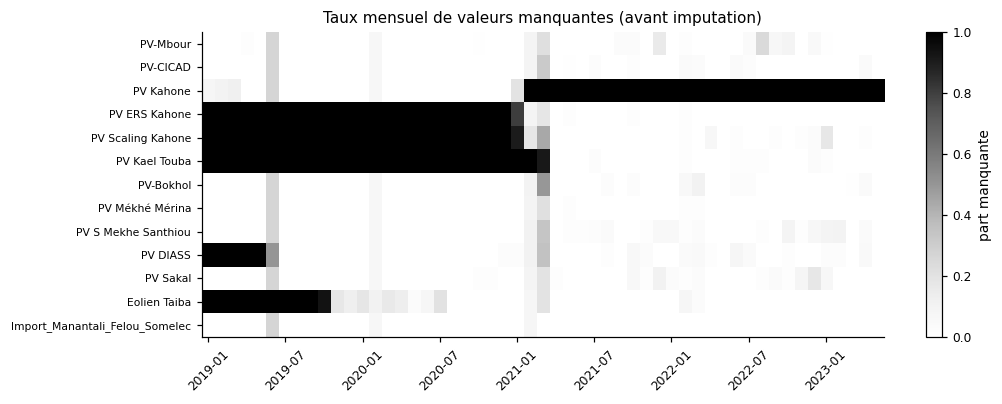

PV-Mbour                           2.7
PV-CICAD                           1.8
PV Kahone                         53.6
PV ERS Kahone                     48.2
PV Scaling Kahone                 49.6
PV Kael Touba                     51.7
PV-Bokhol                          2.3
PV Mékhé Mérina                    1.3
PV S Mekhe Santhiou                2.8
PV DIASS                          12.4
PV Sakal                           2.5
Eolien Taiba                      21.9
Import_Manantali_Felou_Somelec     0.8


In [ ]:
colonnes = m.COLONNES_PV + ["Eolien Taiba", "Import_Manantali_Felou_Somelec"]
manq = journal[colonnes].isna().groupby(journal.index.to_period("M")).mean().T
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(manq.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_yticks(range(len(colonnes)), colonnes, fontsize=7)
xt = range(0, manq.shape[1], 6); ax.set_xticks(list(xt), [str(manq.columns[i]) for i in xt], rotation=45)
fig.colorbar(im, ax=ax, label="part manquante")
ax.set_title("Taux mensuel de valeurs manquantes (avant imputation)"); ax.grid(False)
fs.sauver(fig, "fig02_valeurs_manquantes")
print((journal[colonnes].isna().mean() * 100).round(1).to_string())

> **Lecture.** Les blocs manquants de `PV Kahone`, `PV ERS Kahone`, `PV Scaling Kahone` et `PV Kael Touba` sont **structurels** :
> ils couvrent les périodes où la centrale n'existait pas encore (ou plus). La centrale de Kahone est remplacée par ERS
> et Scaling Kahone le 26/01/2021. Ces périodes valent zéro par définition ; elles ne relèvent pas de l'imputation.

## 4. Saisonnalité

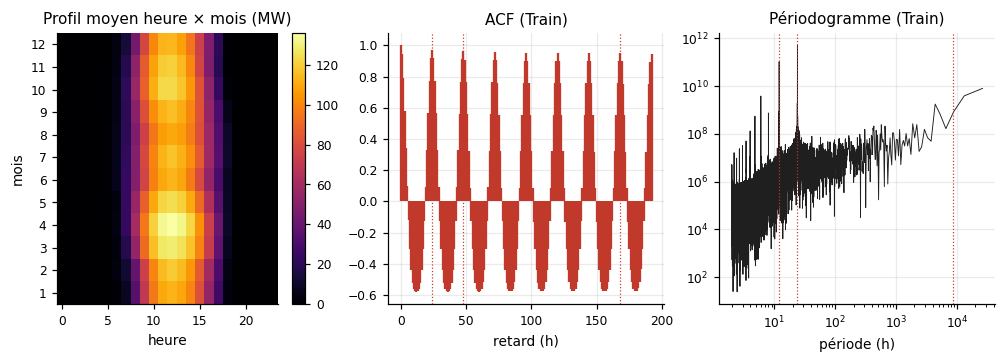

{1: np.float64(0.9416), 23: np.float64(0.917), 24: np.float64(0.9699), 25: np.float64(0.916), 48: np.float64(0.962), 168: np.float64(0.9494)}
Période dominante (h) : 24.0


In [ ]:
from statsmodels.tsa.stattools import acf
y = tab[m.CIBLE]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
prof = y.groupby([y.index.month, y.index.hour]).mean().unstack()
im = ax[0].imshow(prof.values, aspect="auto", cmap="inferno", origin="lower")
ax[0].set_xlabel("heure"); ax[0].set_ylabel("mois"); ax[0].set_yticks(range(12), range(1, 13))
ax[0].set_title("Profil moyen heure × mois (MW)"); fig.colorbar(im, ax=ax[0]); ax[0].grid(False)
r = acf(y[: jeu.i_val], nlags=24 * 8, fft=True)
ax[1].stem(range(len(r)), r, markerfmt=" ", basefmt=" ")
for k in (24, 48, 168): ax[1].axvline(k, color=fs.COULEURS["modele"], ls=":", lw=0.8)
ax[1].set_title("ACF (Train)"); ax[1].set_xlabel("retard (h)")
f = np.fft.rfftfreq(jeu.i_val, d=1); p = np.abs(np.fft.rfft(y[: jeu.i_val] - y[: jeu.i_val].mean())) ** 2
ax[2].loglog(1 / f[1:], p[1:], lw=0.6, color=fs.COULEURS["observe"])
for T in (12, 24, 24 * 365.25): ax[2].axvline(T, color=fs.COULEURS["modele"], ls=":", lw=0.8)
ax[2].set_title("Périodogramme (Train)"); ax[2].set_xlabel("période (h)")
fs.sauver(fig, "fig03_saisonnalite")
print({k: round(r[k], 4) for k in (1, 23, 24, 25, 48, 168)})
print("Période dominante (h) :", round(1 / f[1:][np.argmax(p[1:])], 2))

> **Lecture.** Le cycle journalier domine (ACF(24) ≈ 0,95, pic du périodogramme à 24 h, harmonique à 12 h).
> La période est bien de 24 pas : l'anomalie de période 27 relevée sur l'ancien fichier `production.xlsx` est absente ici.
> Le cycle annuel module l'amplitude : maximum en mars–mai, creux en août–septembre (saison des pluies et nébulosité de mousson).

## 5. Non-stationnarité : croissance du parc installé

In [ ]:
an = y.groupby(y.index.year).agg(["mean", "max"])
an["q99_max_journalier"] = y.resample("D").max().groupby(lambda d: d.year).quantile(0.99)
an.columns = ["moyenne (MW)", "maximum (MW)", "q99 du max journalier (MW)"]
display(an.round(1))
print("Croissance de la moyenne 2019 → 2022 : %+.0f %%" % (100 * (an.iloc[3, 0] / an.iloc[0, 0] - 1)))

,moyenne (MW),maximum (MW),q99 du max journalier (MW)
horodatage,,,
2019,29.9,115.8,114.2
2020,30.8,123.6,120.6
2021,42.1,179.0,176.1
2022,44.0,178.6,176.0
2023,45.7,170.4,169.7


Croissance de la moyenne 2019 → 2022 : +47 %


> **Lecture.** Entre 2019 et 2022, la production moyenne augmente de 47 % à mesure que les centrales entrent en service.
> La série n'est donc **pas stationnaire en niveau**, ce qui justifie la normalisation réversible par fenêtre (RevIN) du modèle
> et l'évaluation de la **dérive** sur un mois de prévision sans ré-entraînement.

## 6. Covariables

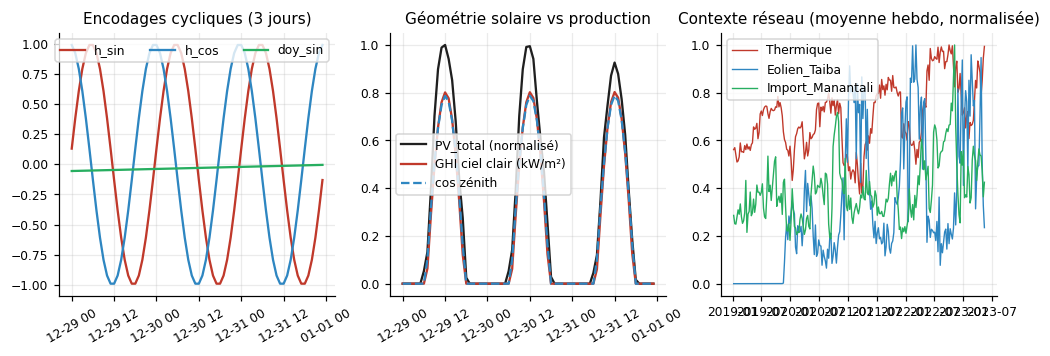

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
j = slice(jeu.i_val - 24 * 3, jeu.i_val)
t = tab.index[j]
ax[0].plot(t, tab["h_sin"].values[j], label="h_sin"); ax[0].plot(t, tab["h_cos"].values[j], label="h_cos")
ax[0].plot(t, tab["doy_sin"].values[j], label="doy_sin"); ax[0].legend(ncol=3); ax[0].set_title("Encodages cycliques (3 jours)")
ax[0].tick_params(axis="x", rotation=30)
yn = tab[m.CIBLE].values[j] / tab[m.CIBLE].values[j].max()
ax[1].plot(t, yn, color=fs.COULEURS["observe"], label="PV_total (normalisé)")
ax[1].plot(t, tab["ghi_ciel_clair"].values[j] / 1000, color=fs.COULEURS["modele"], label="GHI ciel clair (kW/m²)")
ax[1].plot(t, tab["cos_zenith"].values[j], ls="--", color=fs.COULEURS["moyenne"], label="cos zénith")
ax[1].legend(); ax[1].set_title("Géométrie solaire vs production"); ax[1].tick_params(axis="x", rotation=30)
for c in m.CANAUX_RESEAU:
    s = tab[c].resample("W").mean(); ax[2].plot(s.index, s / s.max(), label=c, lw=0.9)
ax[2].legend(); ax[2].set_title("Contexte réseau (moyenne hebdo, normalisée)")
fs.sauver(fig, "fig04_covariables")

**Pourquoi ces covariables ?**
- **Cycliques** (sin/cos de l'heure, du jour de l'année, du jour de la semaine) : elles assurent la continuité aux
  frontières (23 h → 0 h, 31/12 → 01/01). Le jour de semaine n'a aucun lien physique avec l'irradiance : il sert de **témoin négatif** dans l'analyse XAI.
- **Géométrie solaire** (pvlib) : cos de l'angle zénithal et rayonnement de ciel clair (Haurwitz), au barycentre des centrales.
  Elles sont **déterministes**, donc connues sans erreur à tout horizon : ce sont les seules variables disponibles pour le **futur**.
- **Contexte réseau** : production thermique agrégée, éolien de Taiba, import de Manantali. Elles ne sont utilisées que sur la fenêtre **passée**,
  comme « proxy météo » (la demande nette et le régime de vent reflètent l'état de l'atmosphère).

## 7. Corrélations

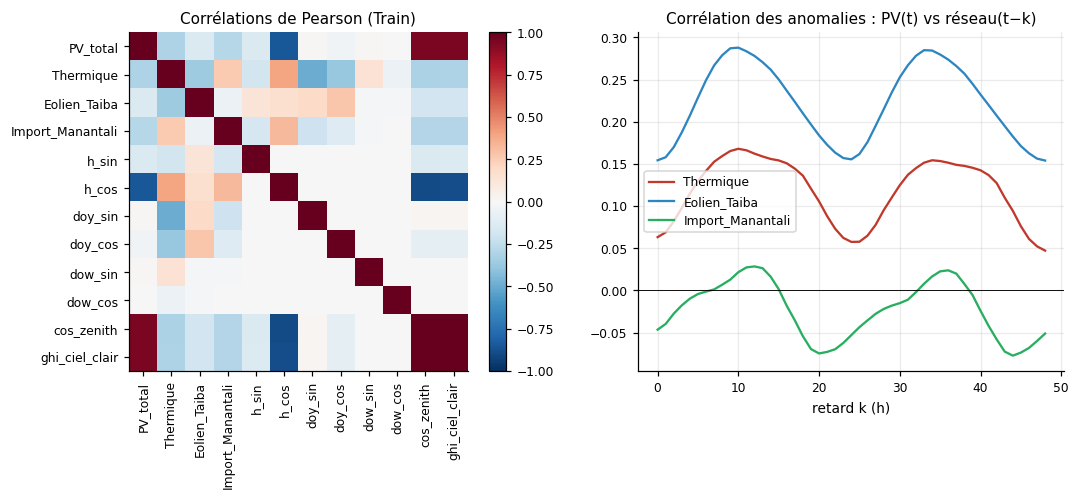

PV_total            1.000
Thermique          -0.305
Eolien_Taiba       -0.145
Import_Manantali   -0.286
h_sin              -0.141
h_cos              -0.847
doy_sin             0.010
doy_cos            -0.033
dow_sin             0.014
dow_cos            -0.004
cos_zenith          0.944
ghi_ciel_clair      0.945


In [ ]:
cor = tab.iloc[: jeu.i_val].corr()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(cor.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(len(cor)), cor.columns, rotation=90); ax[0].set_yticks(range(len(cor)), cor.columns)
fig.colorbar(im, ax=ax[0]); ax[0].set_title("Corrélations de Pearson (Train)"); ax[0].grid(False)
# corrélation croisée cible(t) vs réseau(t-k) sur les résidus journaliers (anomalies)
anom = lambda s: s - s.groupby([s.index.dayofyear, s.index.hour]).transform("mean")
ya = anom(tab[m.CIBLE].iloc[: jeu.i_val])
for c in m.CANAUX_RESEAU:
    xa = anom(tab[c].iloc[: jeu.i_val])
    cc = [ya.corr(xa.shift(k)) for k in range(0, 49)]
    ax[1].plot(range(0, 49), cc, label=c)
ax[1].axhline(0, color="k", lw=0.6); ax[1].legend(); ax[1].set_xlabel("retard k (h)")
ax[1].set_title("Corrélation des anomalies : PV(t) vs réseau(t−k)")
fs.sauver(fig, "fig05_correlations")
print(cor[m.CIBLE].round(3).to_string())

> **Lecture.** La cible est fortement corrélée à la géométrie solaire (cos zénith, ciel clair) et à l'encodage horaire.
> Une fois retiré le cycle moyen, les anomalies de production n'ont qu'une corrélation **faible** avec le contexte
> réseau passé. On peut donc s'attendre à un apport limité des canaux réseau ; l'étude quantifie cet apport (Config 3 et XAI).

## 8. Découpage temporel et normalisation (sans fuite)

In [ ]:
seg = pd.DataFrame({
    "segment": ["Train", "Validation", "Test"],
    "début": [tab.index[0], tab.index[jeu.i_val], tab.index[jeu.i_test]],
    "fin": [tab.index[jeu.i_val - 1], tab.index[jeu.i_test - 1], tab.index[-1]],
    "heures": [jeu.i_val, jeu.i_test - jeu.i_val, len(tab) - jeu.i_test],
})
seg["moyenne PV (MW)"] = [tab[m.CIBLE].iloc[a:b].mean() for a, b in [(0, jeu.i_val), (jeu.i_val, jeu.i_test), (jeu.i_test, len(tab))]]
display(seg)
# Vérifications des règles d'or
assert tab.index[jeu.i_val - 1] < m.DEBUT_VAL <= tab.index[jeu.i_val]            # R1
assert np.allclose(jeu.moyenne, tab.iloc[: jeu.i_val].mean().values)              # R2 : normalisation = Train
assert not set(m.COLONNES_PV + m.COLONNES_EXCLUES) & set(tab.columns)            # R4
print("Règles R1, R2, R4 vérifiées. Canaux du modèle :", m.CANAUX)

,segment,début,fin,heures,moyenne PV (MW)
0,Train,2019-01-01,2021-12-31 23:00:00,26304,34.2683
1,Validation,2022-01-01,2022-09-30 23:00:00,6552,44.5920
2,Test,2022-10-01,2023-05-09 23:00:00,5304,44.2753


Règles R1, R2, R4 vérifiées. Canaux du modèle : ['PV_total', 'Thermique', 'Eolien_Taiba', 'Import_Manantali', 'h_sin', 'h_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'cos_zenith', 'ghi_ciel_clair']


## 9. Conclusions pour la modélisation

1. **Cible propre et traçable.** 11 centrales, 107 valeurs aberrantes écrêtées, lacunes imputées de façon causale, périodes hors service mises à zéro.
2. **Cycle de 24 h dominant** et saisonnalité annuelle d'amplitude : les encodages cycliques et la géométrie solaire décrivent le **déterministe** ;
   le modèle doit apprendre l'**aléatoire** (nébulosité), porté par l'historique récent de la cible.
3. **Non-stationnarité de niveau** (+47 % entre 2019 et 2022) : normalisation par fenêtre (RevIN) et test de dérive.
4. **La persistance journalière sera une référence difficile** : ACF(24) = 0,95.
5. Le jeu de données (12 canaux) est mis en cache pour les notebooks 01 à 05.